# CAPÍTULO 4 – VOLATILIDADE IMPLÍCITA A PARTIR DAS OPÇÕES (API DERIBIT)  
## Construção do Smile, Skew e Superfície Instantânea de Volatilidade

Neste capítulo, deixo de olhar apenas para medidas **agregadas** de volatilidade implícita, como o DVOL e a IV30D, e passo a analisar a estrutura fina da volatilidade extraída diretamente do **mercado de opções de BTC** na Deribit.

O objetivo é:

- Construir o **smile de volatilidade** (IV vs strike);
- Extrair medidas simples de **skew** de volatilidade (puts OTM × calls OTM);
- Destacar como essas informações microestruturais podem complementar o estudo do **BVRP**.

Para garantir **reprodutibilidade acadêmica**, sempre que dados forem obtidos via API, eles serão também salvos em **arquivos estáticos CSV** (por exemplo, `data/options_snapshot.csv` e `data/iv_snapshot.csv`). Assim, os mesmos resultados podem ser reproduzidos mesmo que o mercado já tenha mudado.


In [11]:
# ======================================================
# 4.0 – Imports e configuração geral
# ======================================================

import os
from pathlib import Path
import time

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(".").resolve()
DATA_DIR = BASE_DIR / "data"
FIGS_DIR = BASE_DIR / "figs"

DATA_DIR.mkdir(exist_ok=True, parents=True)
FIGS_DIR.mkdir(exist_ok=True, parents=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("BASE_DIR :", BASE_DIR)
print("DATA_DIR :", DATA_DIR)
print("FIGS_DIR :", FIGS_DIR)


BASE_DIR : C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code
DATA_DIR : C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\data
FIGS_DIR : C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\figs


## 4.1 Introdução: do DVOL agregado à estrutura fina da volatilidade

Nos capítulos anteriores trabalhei com o **DVOL** e a **IV30D** como medidas agregadas de volatilidade implícita.  
Esses índices são úteis para condensar o nível de volatilidade do mercado, mas **não descrevem**:

- como a IV varia ao longo dos **strikes** (smile de volatilidade),
- como a IV muda entre **maturidades**,
- nem como o mercado precifica **riscos assimétricos** (skew).

A partir deste capítulo, passo a analisar **opções individuais** de BTC listadas na Deribit, construindo:

- o **smile de IV** (IV × strike) para um vencimento específico;
- uma medida simples de **skew** (puts OTM vs calls OTM);
- snapshots estáticos que podem ser utilizados tanto para análise quanto para replicação dos resultados.

A API pública da Deribit será a fonte de dados, com o cuidado de registrar tudo em arquivos CSV para garantir **reprodutibilidade acadêmica**.


In [6]:
# ======================================================
# 4.2 – Acesso à API pública da Deribit
# ======================================================

BASE_URL = "https://www.deribit.com/api/v2"


def deribit_get(endpoint: str, params: dict | None = None) -> dict:
    """
    Função auxiliar para requisições GET à API pública da Deribit.

    Parâmetros
    ----------
    endpoint : str
        Caminho do endpoint (ex: '/public/get_instruments').
    params : dict, opcional
        Dicionário com parâmetros da query string.

    Retorno
    -------
    dict
        Campo 'result' do JSON retornado pela API.
    """
    url = f"{BASE_URL}{endpoint}"
    r = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    data = r.json()
    return data["result"]


print("API helper `deribit_get` definido com sucesso.")


API helper `deribit_get` definido com sucesso.


## 4.3 Listagem e organização dos instrumentos de opções de BTC

### 4.3.1 Objetivo

Primeiro, preciso obter **todos os contratos de opções de BTC** disponíveis (calls e puts, todos os strikes e vencimentos não expirados).  
Isso é feito com o endpoint:

- `/public/get_instruments` com `currency = "BTC"` e `kind = "option"`.

Em seguida:

1. Converto a lista de instrumentos em um **DataFrame**;
2. Converto o timestamp de expiração para uma coluna `expiration` em formato de data;
3. Mantenho as colunas principais:  
   `instrument_name`, `strike`, `expiration`, `option_type`.

### 4.3.2 Snapshot estático

Para garantir reprodutibilidade, uso a seguinte lógica:

- Se já existir `data/options_snapshot.csv`, **leio esse arquivo**;
- Caso contrário, **chamo a API**, salvo o resultado em `options_snapshot.csv` e passo a usá-lo como base.


In [7]:
# ======================================================
# 4.3 – Listagem e organização dos instrumentos (snapshot)
# ======================================================

options_snapshot_path = DATA_DIR / "options_snapshot.csv"

if options_snapshot_path.exists():
    print("Lendo instrumentos a partir de snapshot estático:")
    inst_df = pd.read_csv(options_snapshot_path, parse_dates=["expiration"])
else:
    print("Nenhum snapshot encontrado. Consultando API Deribit...")
    instruments = deribit_get(
        "/public/get_instruments",
        {"currency": "BTC", "kind": "option"}
    )
    inst_df = pd.DataFrame(instruments)

    # converte timestamp de expiração para datetime
    inst_df["expiration"] = pd.to_datetime(
        inst_df["expiration_timestamp"], unit="ms"
    )

    # salva snapshot bruto
    cols_to_save = [
        "instrument_name",
        "strike",
        "expiration",
        "option_type",
        "expiration_timestamp",
        "min_trade_amount",
        "tick_size"
    ]
    cols_to_save = [c for c in cols_to_save if c in inst_df.columns]
    inst_df[cols_to_save].to_csv(options_snapshot_path, index=False)
    print("Snapshot salvo em:", options_snapshot_path)

print("Total de opções no snapshot:", len(inst_df))
display(inst_df[["instrument_name", "strike", "expiration", "option_type"]].head())


Lendo instrumentos a partir de snapshot estático:
Total de opções no snapshot: 690


,instrument_name,strike,expiration,option_type
0,BTC-10DEC25-84000-C,84000.0,2025-12-10 08:00:00,call
1,BTC-10DEC25-84000-P,84000.0,2025-12-10 08:00:00,put
2,BTC-10DEC25-85000-C,85000.0,2025-12-10 08:00:00,call
3,BTC-10DEC25-85000-P,85000.0,2025-12-10 08:00:00,put
4,BTC-10DEC25-86000-C,86000.0,2025-12-10 08:00:00,call


## 4.4 Escolha da maturidade e filtragem por vencimento

Para construir o **smile de volatilidade**, seleciono um **vencimento específico** e trabalho apenas com as opções que expiram nessa data.

### Critério básico (padrão)

Como critério inicial, escolho o **vencimento mais próximo** ainda não expirado:

\[
\text{nearest\_expiry} = \min(\text{expiration})
\]

Esse critério pode ser facilmente alterado, por exemplo:

- escolher um vencimento específico por data;
- restringir a maturidades entre 20 e 40 dias;
- comparar smiles de diferentes vencimentos.

A filtragem resulta em um DataFrame `snap_df` contendo apenas as opções desse vencimento.


In [12]:
# ======================================================
# 4.4 – Seleção da maturidade e filtragem por vencimento
# ======================================================

# Garante que inst_df está ordenado por data de expiração
inst_df = inst_df.sort_values("expiration").reset_index(drop=True)

print("Vencimentos únicos disponíveis na amostra:")
print(inst_df["expiration"].drop_duplicates().head(10))  # mostra os 10 primeiros
print("Total de maturities distintas:", inst_df["expiration"].nunique())

# Escolha automática: vencimento mais próximo (menor expiration)
nearest_expiry = inst_df["expiration"].min()
print("\n[4.4] Vencimento selecionado (nearest_expiry):", nearest_expiry)

# Filtra apenas as opções desse vencimento
snap_df = inst_df[inst_df["expiration"] == nearest_expiry].copy()
snap_df = snap_df.reset_index(drop=True)

print("Quantidade de opções nesse vencimento:", len(snap_df))
display(snap_df[["instrument_name", "strike", "option_type"]].head())


Vencimentos únicos disponíveis na amostra:
0     2025-12-10 08:00:00
32    2025-12-11 08:00:00
70    2025-12-12 08:00:00
124   2025-12-13 08:00:00
154   2025-12-19 08:00:00
202   2025-12-26 08:00:00
334   2026-01-30 08:00:00
408   2026-02-27 08:00:00
462   2026-03-27 08:00:00
540   2026-06-26 08:00:00
Name: expiration, dtype: datetime64[ns]
Total de maturities distintas: 11

[4.4] Vencimento selecionado (nearest_expiry): 2025-12-10 08:00:00
Quantidade de opções nesse vencimento: 32


,instrument_name,strike,option_type
0,BTC-10DEC25-84000-C,84000.0,call
1,BTC-10DEC25-87000-P,87000.0,put
2,BTC-10DEC25-90000-P,90000.0,put
3,BTC-10DEC25-90000-C,90000.0,call
4,BTC-10DEC25-89000-P,89000.0,put


## 4.5 Coleta da volatilidade implícita (IV) para cada contrato

Agora, para cada instrumento no vencimento selecionado, preciso obter a **volatilidade implícita de marcação** (`mark_iv`), via endpoint:

- `/public/ticker` com o parâmetro `instrument_name`.

### Observação sobre unidades

- A `mark_iv` fornecida pela Deribit vem em **porcentagem anualizada** (por exemplo, 75.0 = 75% a.a.);
- Crio duas colunas:
  - `iv_pct` – IV em % (como vem da API),
  - `iv_dec` – IV em decimal (IV% / 100).

### Snapshot de IV

Assim como na lista de instrumentos, uso um **snapshot estático**:

- Se existir `data/iv_snapshot.csv`, leio e uso esse arquivo;
- Caso contrário, chamo a API para cada instrumento do vencimento selecionado, salvo o snapshot e passo a trabalhar com ele.


In [13]:
# ======================================================
# 4.5 – Coleta da volatilidade implícita (mark_iv) por contrato
# ======================================================

def get_mark_iv(instrument_name: str) -> float:
    """
    Consulta a API da Deribit para obter a volatilidade implícita (mark_iv)
    de um instrumento específico.

    IMPORTANTE:
    - A Deribit retorna `mark_iv` em PERCENTUAL anualizado (ex: 79.31 = 79.31% a.a.)
    - Aqui vamos guardar:
        * iv_pct  = em %  (ex: 79.31)
        * iv_dec  = em decimal (ex: 0.7931)
    """
    res = deribit_get("/public/ticker", {"instrument_name": instrument_name})
    return res["mark_iv"]  # em % a.a. segundo a documentação / comportamento observado


ivs = []
for name in snap_df["instrument_name"]:
    iv = get_mark_iv(name)
    ivs.append(iv)
    time.sleep(0.05)  # pequena pausa para não sobrecarregar a API

# 1) Guarda o valor bruto retornado pela API
snap_df["mark_iv"] = ivs  # em % a.a. (ex: 79.31)

# 2) Normaliza para duas versões:
#    - iv_pct: em % (mesmo valor do mark_iv, só com nome mais claro)
#    - iv_dec: em decimal (0.7931 = 79.31%)

snap_df["iv_pct"] = snap_df["mark_iv"].astype(float)
snap_df["iv_dec"] = snap_df["iv_pct"] / 100.0

print("\n[4.5] Prévia com IVs coletadas:")
display(snap_df[["instrument_name", "strike", "option_type", "iv_dec", "iv_pct"]].head())

# (opcional, mas bom para a dissertação – snapshot estático)
iv_snapshot_path = DATA_DIR / "iv_smile_snapshot.csv"
snap_df.to_csv(iv_snapshot_path, index=False)
print("Snapshot de smile/IV salvo em:", iv_snapshot_path)



[4.5] Prévia com IVs coletadas:


,instrument_name,strike,option_type,iv_dec,iv_pct
0,BTC-10DEC25-84000-C,84000.0,call,0.7931,79.31
1,BTC-10DEC25-87000-P,87000.0,put,0.7829,78.29
2,BTC-10DEC25-90000-P,90000.0,put,0.5282,52.82
3,BTC-10DEC25-90000-C,90000.0,call,0.5282,52.82
4,BTC-10DEC25-89000-P,89000.0,put,0.5987,59.87


Snapshot de smile/IV salvo em: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\data\iv_smile_snapshot.csv


In [13]:
# ======================================================
# 4.5 – Coleta da volatilidade implícita (mark_iv) por contrato
# ======================================================
"""
Neste bloco, consultamos a API pública da Deribit (endpoint /public/ticker)
para obter a volatilidade implícita (mark_iv) de cada contrato de opção
do vencimento selecionado em 4.4.

- A Deribit retorna mark_iv em PERCENTUAL (ex.: 79.31 = 79.31% a.a.);
- Criamos:
    - iv_pct  → IV em % (para gráficos);
    - iv_dec  → IV em decimal (para cálculos).
- Salvamos o snapshot completo em DATA_DIR / 'iv_smile_snapshot.csv'.
"""

# --- checagens básicas ---
try:
    snap_df
except NameError:
    raise RuntimeError(
        "snap_df não está definido. Execute antes as células 4.3 e 4.4."
    )

from math import isnan

def get_mark_iv(instrument_name: str) -> float:
    """
    Consulta a API da Deribit para obter a volatilidade implícita (mark_iv)
    de um instrumento específico.

    Retorna a IV em PERCENTUAL, ex: 79.31 = 79.31% a.a.
    """
    res = deribit_get("/public/ticker", {"instrument_name": instrument_name})
    return res["mark_iv"]  # Deribit retorna em %

ivs = []
for name in snap_df["instrument_name"]:
    iv = get_mark_iv(name)
    ivs.append(iv)
    time.sleep(0.05)  # pequena pausa para não sobrecarregar a API

# Cria colunas de IV
snap_df["iv_pct"] = np.array(ivs, dtype=float)      # IV em %
snap_df["iv_dec"] = snap_df["iv_pct"] / 100.0       # IV em decimal

print("\n[4.5] Prévia com IVs coletadas:")
display(snap_df[["instrument_name", "strike", "option_type", "iv_dec", "iv_pct"]].head())

# (opcional, mas bom para reprodutibilidade da dissertação)
iv_snapshot_path = DATA_DIR / "iv_smile_snapshot.csv"
snap_df.to_csv(iv_snapshot_path, index=False)
print("Snapshot de smile/IV salvo em:", iv_snapshot_path)



[4.5] Prévia com IVs coletadas:


,instrument_name,strike,option_type,iv_dec,iv_pct
0,BTC-10DEC25-84000-C,84000.0,call,0.7931,79.31
1,BTC-10DEC25-87000-P,87000.0,put,0.7829,78.29
2,BTC-10DEC25-90000-P,90000.0,put,0.5151,51.51
3,BTC-10DEC25-90000-C,90000.0,call,0.5151,51.51
4,BTC-10DEC25-89000-P,89000.0,put,0.5987,59.87


Snapshot de smile/IV salvo em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\data\iv_smile_snapshot.csv


## 4.6 Construção do *smile* de volatilidade implícita

Com as IVs em mãos, posso construir o **smile de volatilidade** para o vencimento selecionado.

### Passos:

1. Seleciono apenas as **calls** (o mesmo poderia ser feito para puts);
2. Organizo o DataFrame por strike;
3. Faço o gráfico de `iv_pct` contra `strike`.

Em um modelo Black–Scholes puro, a volatilidade seria constante (linha reta).  
Na prática, observamos formatos em **sorriso** (*smile*) ou **inclinação** (*skew*), refletindo:

- assimetria na distribuição implícita de retornos;
- maior demanda por proteção em determinados strikes;
- prêmios de risco específicos para cenários de queda ou alta.

Este gráfico captura a **estrutura transversal** da volatilidade implícita para uma dada maturidade.



[4.6] Nº de opções no vencimento 2025-12-10:
Calls: 16  | Puts: 16


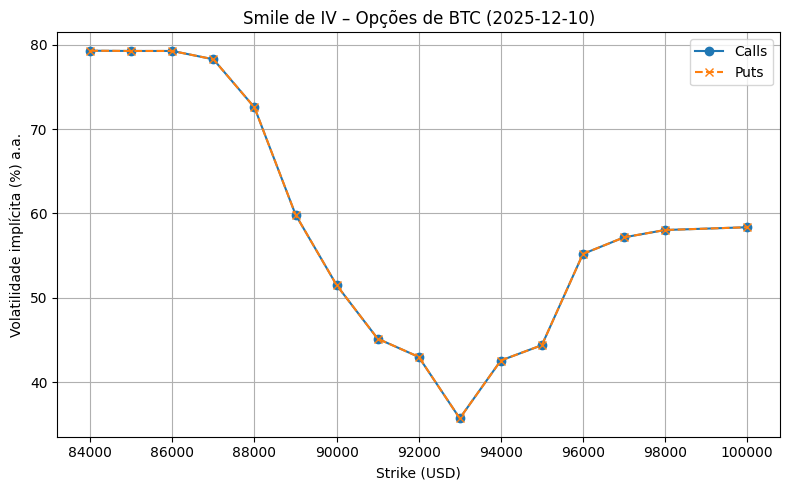

Figura do smile salva em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\figs\smile_iv_btc_2025-12-10.png


In [14]:
# ======================================================
# 4.6 – Smile de volatilidade implícita (calls x puts)
# ======================================================
"""
Neste bloco, construímos o smile de volatilidade implícita (IV × strike)
para o vencimento selecionado em 4.4 (nearest_expiry).

- Usamos a IV em percentual (iv_pct) para o eixo vertical;
- Separamos calls e puts para visualizar possíveis assimetrias;
- Salvamos a figura em FIGS_DIR para uso na dissertação.
"""

# 1) Garante que temos snap_df com IVs
iv_snapshot_path = DATA_DIR / "iv_smile_snapshot.csv"

if "iv_pct" not in globals().get("snap_df", pd.DataFrame()).columns:
    # tenta recarregar do snapshot com IV
    if iv_snapshot_path.exists():
        snap_df = pd.read_csv(iv_snapshot_path)
        print("[4.6] snap_df recarregado de:", iv_snapshot_path)
    else:
        raise RuntimeError(
            "Coluna 'iv_pct' não encontrada em snap_df e "
            "o arquivo iv_smile_snapshot.csv não existe.\n"
            "→ Rode as células 4.4 e 4.5 antes de 4.6."
        )

# se ainda assim não tiver iv_pct, tenta reconstruir a partir de iv_dec
if "iv_pct" not in snap_df.columns:
    if "iv_dec" in snap_df.columns:
        snap_df["iv_pct"] = snap_df["iv_dec"] * 100.0
        print("[4.6] Coluna 'iv_pct' reconstruída a partir de 'iv_dec'.")
    else:
        raise RuntimeError(
            "Nem 'iv_pct' nem 'iv_dec' encontrados em snap_df.\n"
            "→ Rode a célula 4.5 para calcular as IVs."
        )

# Garante que temos as colunas essenciais
assert "strike" in snap_df.columns, "Coluna 'strike' não encontrada em snap_df."
assert "option_type" in snap_df.columns, "Coluna 'option_type' não encontrada em snap_df."

# 2) Separa calls e puts
calls = snap_df[snap_df["option_type"] == "call"].copy()
puts  = snap_df[snap_df["option_type"] == "put"].copy()

# Ordena por strike para um smile mais “suave” visualmente
calls = calls.sort_values("strike")
puts  = puts.sort_values("strike")

print(f"\n[4.6] Nº de opções no vencimento {nearest_expiry.date()}:")
print("Calls:", len(calls), " | Puts:", len(puts))

# 3) Plot do smile
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(calls["strike"], calls["iv_pct"], marker="o", linestyle="-", label="Calls")
ax.plot(puts["strike"],  puts["iv_pct"],  marker="x", linestyle="--", label="Puts")

ax.set_title(f"Smile de IV – Opções de BTC ({nearest_expiry.date()})")
ax.set_xlabel("Strike (USD)")
ax.set_ylabel("Volatilidade implícita (%) a.a.")
ax.legend()
ax.grid(True)

plt.tight_layout()

# Caminho da figura
smile_path = FIGS_DIR / f"smile_iv_btc_{nearest_expiry.date()}.png"
plt.savefig(smile_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura do smile salva em:", smile_path)


## 4.7 Cálculo de uma medida simples de skew de volatilidade

Para quantificar a assimetria do smile, calculo uma medida simples de **skew de volatilidade**:

1. Defino um **strike ATM** aproximado;
2. Separo:
   - **puts OTM** – strikes abaixo do ATM;
   - **calls OTM** – strikes acima do ATM;
3. Calculo:
\[
\text{Skew} = \overline{\text{IV}_{\text{puts OTM}}} - \overline{\text{IV}_{\text{calls OTM}}}
\]

- Se o skew for **positivo**, puts OTM têm IV média maior que calls OTM → o mercado paga mais por proteção contra **quedas**;
- Se for **negativo**, a assimetria está favorecendo calls (cenários de alta).

### Escolha do strike ATM

Como aproximação simples, defino o ATM como o strike da call com **menor IV**, dentro desse vencimento.  
Alternativas possíveis:

- usar o preço spot do BTC (se disponível) e escolher o strike mais próximo;
- usar deltas (25-delta puts/calls);
- restringir o cálculo a uma faixa de moneyness específica.

Aqui opto pela versão mais simples, suficiente como **primeira medida de skew**.


In [15]:
# ======================================================
# 4.7 – Cálculo do Skew de Volatilidade
# ======================================================
"""
Aqui calculamos três medidas importantes de skew:
1) skew_simple = média(IV puts OTM) – média(IV calls OTM)
2) skew_pct = skew_simple em pontos de volatilidade (%)
3) skew_reg = coeficiente da regressão IV ~ strike (aproxima moneyness)

Essas medidas serão usadas depois como features para ML (Capítulo 5).
"""

# -------------------------
# 1. Determinar o strike ATM
# -------------------------
atm_row = snap_df.loc[snap_df["iv_dec"].idxmin()]      # menor IV ≈ ATM
atm_strike = atm_row["strike"]

print(f"[4.7] Strike ATM aproximado: {atm_strike}")

# -------------------------
# 2. Separar puts OTM e calls OTM
# -------------------------
puts_otm  = snap_df[(snap_df["option_type"] == "put")  & (snap_df["strike"] < atm_strike)]
calls_otm = snap_df[(snap_df["option_type"] == "call") & (snap_df["strike"] > atm_strike)]

print("Puts OTM:", len(puts_otm), " | Calls OTM:", len(calls_otm))

# -------------------------
# 3. Cálculo do skew simples
# -------------------------
skew_simple = puts_otm["iv_pct"].mean() - calls_otm["iv_pct"].mean()
print(f"Skew simples (puts - calls): {skew_simple:.4f} pontos de vol")

# ---------------------------------------------------------
# 4. Skew via regressão IV_pct ~ strike (proxy para moneyness)
# ---------------------------------------------------------
from sklearn.linear_model import LinearRegression

X = snap_df["strike"].values.reshape(-1, 1)
y = snap_df["iv_pct"].values

reg = LinearRegression().fit(X, y)
skew_reg = reg.coef_[0]

print(f"Skew via regressão (coef. linear): {skew_reg:.6f}")

# ---------------------------------------------------------
# 5. Salvar tudo no snapshot para uso posterior
# ---------------------------------------------------------
snap_df["atm_strike"] = atm_strike
snap_df["skew_simple"] = skew_simple
snap_df["skew_reg"] = skew_reg

final_skew_path = DATA_DIR / "iv_smile_snapshot_with_skew.csv"
snap_df.to_csv(final_skew_path, index=False)

print("Arquivo salvo com skew em:", final_skew_path)


[4.7] Strike ATM aproximado: 93000.0
Puts OTM: 9  | Calls OTM: 6
Skew simples (puts - calls): 12.7422 pontos de vol
Skew via regressão (coef. linear): -0.001932
Arquivo salvo com skew em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\data\iv_smile_snapshot_with_skew.csv


## 4.8 Visualização complementar: IV por tipo de opção e marcação do ATM

Para interpretar melhor o skew, é útil visualizar o smile completo (puts + calls) e destacar o strike ATM utilizado no cálculo.

No gráfico a seguir:

- círculos azuis representam **calls**;
- triângulos laranja representam **puts**;
- a linha vertical indica o **strike ATM aproximado**.


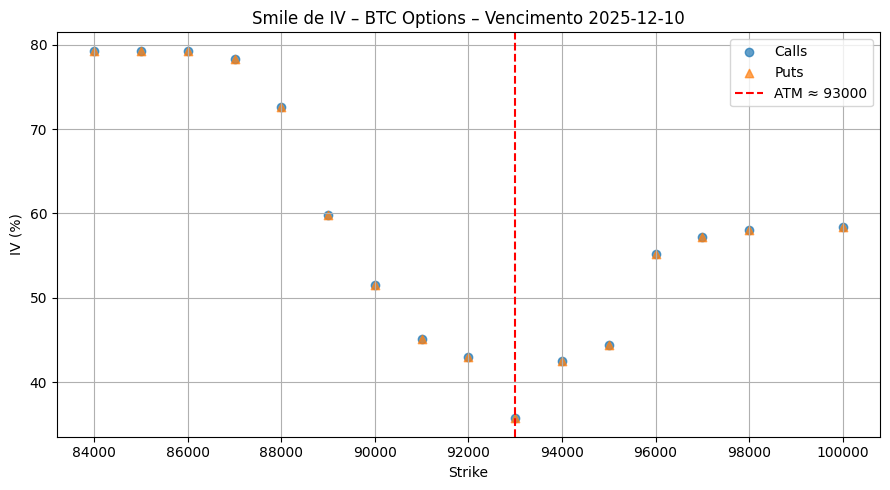

Figura smile (puts + calls + ATM) salva em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\figs\smile_iv_calls_puts_nearest_expiry.png


In [16]:
# ======================================================
# 4.8 – Gráfico combinado de smile (puts + calls) com ATM
# ======================================================

plt.figure(figsize=(9, 5))

calls = snap_df[snap_df["option_type"] == "call"].copy()
puts = snap_df[snap_df["option_type"] == "put"].copy()

plt.scatter(calls["strike"], calls["iv_pct"], label="Calls", marker="o", alpha=0.7)
plt.scatter(puts["strike"], puts["iv_pct"], label="Puts", marker="^", alpha=0.7)

plt.axvline(atm_strike, color="red", linestyle="--", label=f"ATM ≈ {atm_strike:.0f}")

plt.xlabel("Strike")
plt.ylabel("IV (%)")
plt.title(f"Smile de IV – BTC Options – Vencimento {nearest_expiry.date()}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

fig_path2 = FIGS_DIR / "smile_iv_calls_puts_nearest_expiry.png"
plt.figure(figsize=(9, 5))
plt.scatter(calls["strike"], calls["iv_pct"], label="Calls", marker="o", alpha=0.7)
plt.scatter(puts["strike"], puts["iv_pct"], label="Puts", marker="^", alpha=0.7)
plt.axvline(atm_strike, color="red", linestyle="--", label=f"ATM ≈ {atm_strike:.0f}")
plt.xlabel("Strike")
plt.ylabel("IV (%)")
plt.title(f"Smile de IV – BTC Options – Vencimento {nearest_expiry.date()}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_path2, dpi=300, bbox_inches="tight")
plt.close()

print("Figura smile (puts + calls + ATM) salva em:", fig_path2)


# 4.9 Comentários finais do capítulo

Neste capítulo:

1. Acessei a **API pública da Deribit** e construí snapshots estáticos dos 
   instrumentos de opções (`options_snapshot.csv`) e das suas respectivas IVs (`iv_snapshot.csv`);

2. Filtrei um **vencimento específico** (nearest expiry) e construí o **smile de IV** 
   para as opções de BTC;

3. Calculei uma métrica simples de **skew de volatilidade**, baseada na diferença de 
   IV média entre puts OTM e calls OTM;

4. Gerei gráficos salvos em `figs/` que serão utilizados diretamente na dissertação.

Esses resultados complementam o estudo do **BVRP** ao revelar a **estrutura cruzada** 
da volatilidade implícita, mostrando como o mercado precifica riscos em diferentes 
strikes e como isso se relaciona com proteções contra quedas.

Nos próximos capítulos, essas informações podem ser utilizadas como **features adicionais** 
em modelos de regimes de volatilidade ou em previsões do prêmio de risco de volatilidade.


## 4.10 Registro histórico do skew de volatilidade

Para utilizar o *skew* como feature em modelos de ML, preciso armazenar 
os valores calculados em um **histórico temporal**.

A cada execução deste notebook:

- atualizo `data/skew_history.csv`,
- registrando:  
  `date`, `expiration`, `atm_strike`, `skew_simple`.

Esse histórico permitirá mesclar o skew ao dataset principal do BVRP.


In [17]:
# ======================================================
# 4.10 – Registro histórico do skew (skew_history.csv)
# ======================================================

from datetime import datetime

# ------------------------------------------------------
# Garantindo que variáveis essenciais existem no escopo
# ------------------------------------------------------
try:
    DATA_DIR
except NameError:
    raise RuntimeError("DATA_DIR não existe. Execute as células 4.0 → 4.5 antes de 4.10.")

for var in ["nearest_expiry", "atm_strike", "skew_simple"]:
    if var not in globals():
        raise RuntimeError(f"Variável '{var}' não existe. Execute o bloco 4.7 antes de 4.10.")

# ------------------------------------------------------
# Caminho do arquivo
# ------------------------------------------------------
skew_history_path = DATA_DIR / "skew_history.csv"

# Data do snapshot (pode ser fixada se você quiser replicar)
data_snapshot = datetime.utcnow().date()
# Exemplo se quiser fixar manualmente:
# data_snapshot = pd.Timestamp("2024-12-08").date()

# ------------------------------------------------------
# Linha a adicionar ao histórico
# ------------------------------------------------------
row = pd.DataFrame({
    "date": [pd.to_datetime(data_snapshot)],
    "expiration": [nearest_expiry],
    "atm_strike": [atm_strike],
    "skew_simple": [skew_simple],
})

# ------------------------------------------------------
# Atualização do arquivo histórico
# ------------------------------------------------------
if skew_history_path.exists():
    hist = pd.read_csv(skew_history_path, parse_dates=["date", "expiration"])
    hist = hist[hist["date"] != row.loc[0, "date"]]  # remove duplicadas
    hist = pd.concat([hist, row], ignore_index=True)
else:
    hist = row

hist = hist.sort_values("date").reset_index(drop=True)
hist.to_csv(skew_history_path, index=False)

print("Histórico de skew salvo em:", skew_history_path)
display(hist.tail())


Histórico de skew salvo em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\data\skew_history.csv


C:\Users\EM2024006937\AppData\Local\Temp\ipykernel_25048\1068637631.py:25: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  data_snapshot = datetime.utcnow().date()


,date,expiration,atm_strike,skew_simple
0,2025-12-10,2025-12-10 08:00:00,93000.0,12.742222


## 4.11 Integração do *skew* ao dataset de ML

Com o histórico de *skew* salvo em `data/skew_history.csv`, posso integrar essa 
informação ao dataset principal de BVRP, `data/dataset_bvrp_full.csv`.

A ideia é fazer um *merge* por data, criando novas colunas no dataset de ML:

- **`skew_simple_nearest`** – valor do *skew* de volatilidade para o vencimento 
  mais próximo disponível na Deribit na data do snapshot;
- **`skew_expiration_nearest`** – data de vencimento utilizada para calcular esse *skew*.

Quando não houver registro de *skew* para determinada data, essas colunas ficam
como `NaN`, o que preserva a estrutura temporal original do dataset.

O dataset resultante, salvo como `data/dataset_bvrp_with_skew.csv`, passa a 
combinar:

- as informações de volatilidade agregada (IV30D, RV30D, VRP30D),
- os retornos futuros em diferentes horizontes,
- e uma medida de assimetria da superfície de volatilidade (o *skew* do vencimento mais próximo).

Esse arquivo será a base para os modelos de **machine learning**, permitindo 
testar se o *skew* contém informação adicional relevante para explicar ou 
prever o prêmio de risco de volatilidade do Bitcoin.


In [18]:
# ======================================================
# 4.11 – Merge do skew com dataset_bvrp_full
# ======================================================

dataset_path = DATA_DIR / "dataset_bvrp_full.csv"
skew_history_path = DATA_DIR / "skew_history.csv"
dataset_with_skew_path = DATA_DIR / "dataset_bvrp_with_skew.csv"

# carrega dataset principal
df_bvrp = pd.read_csv(dataset_path, parse_dates=["date"])

# carrega histórico de skew
if skew_history_path.exists():
    skew_hist = pd.read_csv(skew_history_path, parse_dates=["date", "expiration"])
else:
    raise FileNotFoundError(
        f"Arquivo {skew_history_path} não encontrado. "
        "Execute antes o notebook 04_smile_skew_deribit.ipynb para gerar o histórico."
    )

# renomeia colunas para ficar claro no dataset final
skew_hist_ren = skew_hist.rename(columns={
    "skew_simple": "skew_simple_nearest",
    "expiration": "skew_expiration_nearest"
})

# merge por data (left join: mantém todas as datas do df_bvrp)
df_merged = pd.merge(
    df_bvrp,
    skew_hist_ren[["date", "skew_simple_nearest", "skew_expiration_nearest"]],
    on="date",
    how="left"
)

df_merged.to_csv(dataset_with_skew_path, index=False)

print("Dataset com skew salvo em:", dataset_with_skew_path)
print("Shape (antes, depois):", df_bvrp.shape, "→", df_merged.shape)
display(df_merged.tail())


Dataset com skew salvo em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\data\dataset_bvrp_with_skew.csv
Shape (antes, depois): (1288, 16) → (1288, 18)


,date,btc_close,ret,rv_7d,rv_14d,rv_30d,rv_60d,iv_30d,iv_30d_dec,vrp_30d,ret_fut_1d,ret_fut_5d,ret_fut_10d,ret_fut_20d,ret_fut_30d,ret_fut_60d,skew_simple_nearest,skew_expiration_nearest
1283,2024-10-28,69962.21,0.028128,0.886345,1.105274,2.053063,3.009011,57.78,0.5778,-1.475263,0.038887,-0.008432,0.080906,0.250253,0.314966,0.298516,NaN,NaT
1284,2024-10-29,72736.42,0.038887,1.156448,1.301097,2.182082,3.098444,59.83,0.5983,-1.583782,-0.005399,-0.055988,0.050576,0.218111,0.273791,0.270188,NaN,NaT
1285,2024-10-30,72344.74,-0.005399,1.140806,1.295961,2.077903,3.099781,59.11,0.5911,-1.486803,-0.028785,-0.064143,0.058165,0.243718,0.297999,0.259063,NaN,NaT
1286,2024-10-31,70292.01,-0.028785,1.189974,1.406695,2.004340,3.099853,58.23,0.5823,-1.422040,-0.011389,-0.013175,0.133983,0.293681,0.315931,0.277703,NaN,NaT
1287,2024-11-01,69496.01,-0.011389,1.132631,1.395003,2.015514,3.048870,59.77,0.5977,-1.417814,-0.001747,0.083816,0.243404,0.346929,0.335349,0.297505,NaN,NaT


## 4.12 Construção de um histórico de skew a partir de múltiplos snapshots

O procedimento das Seções 4.6–4.10 calcula o skew de volatilidade implícita
para **um único dia**, associado ao snapshot atual da cadeia de opções da Deribit.

Para utilizar essa informação em modelos de regime de volatilidade ou em
previsões do BVRP, é desejável construir um **histórico temporal de skew**,
com vários pontos ao longo do tempo.

A estratégia adotada neste trabalho é:

1. Obter, para diferentes datas $t$, snapshots da superfície de IV
   (por exemplo, arquivos CSV com as colunas `strike`, `option_type`,
   `iv_pct`, `expiration`, etc.).
2. Armazenar esses arquivos na pasta `data/` com um padrão de nome, por exemplo  
   `iv_smile_snapshot_YYYYMMDD.csv`.
3. Para cada snapshot:
   - identificar o strike ATM aproximado,
   - separar puts OTM e calls OTM,
   - calcular o *skew* simples como diferença entre as IVs médias,
   - registrar o resultado numa tabela histórica.

O código abaixo automatiza esse processo, varrendo todos os arquivos
`iv_smile_snapshot_*.csv` na pasta `data/` e reconstruindo o arquivo
`skew_history.csv` com um registro por data:

- `date` – data de referência do snapshot;
- `expiration` – vencimento utilizado;
- `atm_strike` – strike ATM aproximado;
- `skew_simple` – skew simples (IV média de puts OTM – IV média de calls OTM).

Esse histórico será, em seguida, integrado ao `dataset_bvrp_full.csv`,
gerando o `dataset_bvrp_with_skew.csv` utilizado na etapa de Machine Learning.


In [19]:
# ======================================================
# 4.12 – Construção do histórico de skew a partir de múltiplos snapshots
# ======================================================
"""
Este bloco varre todos os arquivos 'iv_smile_snapshot_*.csv' em DATA_DIR,
calcula o skew simples para cada snapshot e reconstrói o arquivo
'data/skew_history.csv' com um registro por data.

Pré-requisitos:
- Cada CSV deve ter, no mínimo, as colunas:
    - 'strike'
    - 'option_type'  (valores 'call' ou 'put')
    - 'iv_pct'       (IV em % a.a.)
    - 'expiration'   (timestamp ou string de data de vencimento)

Convenção de nomes de arquivo (recomendada):
- iv_smile_snapshot_YYYYMMDD.csv
  Ex.: iv_smile_snapshot_20241208.csv

O código extrai a data 'YYYYMMDD' do nome do arquivo para preencher a coluna 'date'.
"""

from pathlib import Path
import pandas as pd
import numpy as np

# Garante que DATA_DIR existe (caso esteja rodando este bloco isoladamente)
try:
    DATA_DIR
except NameError:
    BASE_DIR = Path("..").resolve() if Path("code").exists() else Path(".").resolve()
    DATA_DIR = BASE_DIR / "data"

print("DATA_DIR para os snapshots:", DATA_DIR)

# Lista de arquivos de snapshots de IV
snapshot_files = sorted(DATA_DIR.glob("iv_smile_snapshot_*.csv"))

if not snapshot_files:
    raise FileNotFoundError(
        "Nenhum arquivo 'iv_smile_snapshot_*.csv' encontrado em DATA_DIR.\n"
        "Salve primeiro um ou mais snapshots com esse padrão de nome."
    )

rows = []

for f in snapshot_files:
    print(f"\nProcessando snapshot: {f.name}")
    
    # Extrai data do nome do arquivo: iv_smile_snapshot_YYYYMMDD.csv
    # Caso o padrão não seja exatamente esse, ajuste aqui.
    stem = f.stem  # ex.: "iv_smile_snapshot_20241208"
    try:
        date_str = stem.replace("iv_smile_snapshot_", "")
        snapshot_date = pd.to_datetime(date_str, format="%Y%m%d").date()
    except Exception:
        # fallback: tenta inferir diretamente
        snapshot_date = pd.to_datetime(stem.split("_")[-1], errors="coerce").date()
    
    df_snap = pd.read_csv(f)
    
    # Checagens mínimas de colunas
    required_cols = {"strike", "option_type", "iv_pct"}
    if not required_cols.issubset(df_snap.columns):
        print(f"⚠️  Pulando {f.name}: colunas necessárias ausentes.")
        continue
    
    # Se existir coluna de expiration, usa; senão, coloca NaT (não obrigatório para o skew)
    if "expiration" in df_snap.columns:
        expiration = pd.to_datetime(df_snap["expiration"].iloc[0])
    else:
        expiration = pd.NaT
    
    # Separa calls e puts
    calls = df_snap[df_snap["option_type"] == "call"].copy()
    puts  = df_snap[df_snap["option_type"] == "put"].copy()
    
    if calls.empty or puts.empty:
        print(f"⚠️  Snapshot {f.name} sem calls ou sem puts. Pulando.")
        continue
    
    # Identifica ATM como call com menor IV (poderia ser outro critério)
    atm_idx = calls["iv_pct"].idxmin()
    atm_strike = calls.loc[atm_idx, "strike"]
    
    # Define puts OTM (strike < ATM) e calls OTM (strike > ATM)
    puts_otm  = df_snap[(df_snap["option_type"] == "put")  & (df_snap["strike"] < atm_strike)]
    calls_otm = df_snap[(df_snap["option_type"] == "call") & (df_snap["strike"] > atm_strike)]
    
    if puts_otm.empty or calls_otm.empty:
        print(f"⚠️  Snapshot {f.name} sem puts OTM ou calls OTM. Pulando.")
        continue
    
    mean_put  = puts_otm["iv_pct"].mean()
    mean_call = calls_otm["iv_pct"].mean()
    skew_simple = mean_put - mean_call  # em pontos de volatilidade (p.p.)
    
    rows.append({
        "date": pd.to_datetime(snapshot_date),
        "expiration": expiration,
        "atm_strike": atm_strike,
        "skew_simple": skew_simple,
    })
    
    print(f"  → date={snapshot_date}, ATM={atm_strike}, skew_simple={skew_simple:.4f}")

# Monta DataFrame final
if not rows:
    raise RuntimeError("Nenhum skew válido foi calculado. Verifique os snapshots.")

hist = (
    pd.DataFrame(rows)
    .sort_values("date")
    .reset_index(drop=True)
)

skew_history_path = DATA_DIR / "skew_history.csv"
hist.to_csv(skew_history_path, index=False)

print("\n✅ Histórico de skew reconstruído a partir dos snapshots.")
print("Arquivo salvo em:", skew_history_path)
display(hist.tail())


DATA_DIR para os snapshots: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\data

Processando snapshot: iv_smile_snapshot_with_skew.csv
  → date=NaT, ATM=93000.0, skew_simple=12.7422

✅ Histórico de skew reconstruído a partir dos snapshots.
Arquivo salvo em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code\data\skew_history.csv


,date,expiration,atm_strike,skew_simple
0,NaT,2025-12-10 08:00:00,93000.0,12.742222
